<a href="https://colab.research.google.com/github/adaleidman/Data_Science_Project_AL/blob/main/DataCollectionAL%2BProjectFinalUpdated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# 1. Data Collection
# 1.1 Install libraries

!pip install yfinance pandas numpy

In [24]:
# 1.2 Import

import yfinance as yf
import pandas as pd
import numpy as np
import os

In [25]:
# 1.3 Download the S&P 500 data

end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=15)

df = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)

# flatten columns if needed, keep the five we want
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.rename(columns=str.title)[["Open", "High", "Low", "Close", "Volume"]]
df.index.name = "Date"

print("Downloaded", len(df), "rows, from", df.index.min().date(), "to", df.index.max().date())
df.head()

Downloaded 3772 rows, from 2011-06-20 to 2026-06-18


Price,Open,High,Low,Close,Volume
Date,,,,,
2011-06-20,1271.500000,1280.420044,1267.560059,1278.359985,3464660000
2011-06-21,1278.400024,1297.619995,1278.400024,1295.520020,4056150000
2011-06-22,1295.479980,1298.609985,1286.790039,1287.140015,3718420000
2011-06-23,1286.599976,1286.599976,1262.869995,1283.500000,4983450000
2011-06-24,1283.040039,1283.930054,1267.239990,1268.449951,3665340000


In [26]:
# 1.4 Save the raw data

os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/sp500_raw.csv")
print("Saved data/raw/sp500_raw.csv")

Saved data/raw/sp500_raw.csv


In [27]:
# 1.5 Returns

df["return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [28]:
# 1.6 Moving averages (trend)

for w in (10, 20, 50):
    df[f"sma_{w}"] = df["Close"].rolling(w).mean()
df["ema_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["ema_26"] = df["Close"].ewm(span=26, adjust=False).mean()


In [29]:
# 1.7 RSI (momentum)

delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

In [30]:
# 1.8 MACD (trend/momentum)

df["macd"] = df["ema_12"] - df["ema_26"]
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

In [31]:
# 1.9 Bollinger Bands (volatility)

mid = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()
df["bb_upper"] = mid + 2 * std
df["bb_lower"] = mid - 2 * std
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / mid

In [32]:
# 1.10 ATR and momentum

prev_close = df["Close"].shift(1)
tr = pd.concat([df["High"] - df["Low"],
                (df["High"] - prev_close).abs(),
                (df["Low"] - prev_close).abs()], axis=1).max(axis=1)
df["atr_14"] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
df["momentum_10"] = df["Close"] - df["Close"].shift(10)

In [33]:
# 1.10b External features: VIX (volatility) + 10-year Treasury yield (rates)
# drop first so this cell is safe to re-run
df = df.drop(columns=["vix", "yield_10y", "vix_change", "yield_change"],
             errors="ignore")

extra = yf.download(["^VIX", "^TNX"], start=start, end=end,
                    auto_adjust=True, progress=False)["Close"]
extra.columns = [str(c).replace("^", "") for c in extra.columns]
extra = extra.rename(columns={"VIX": "vix", "TNX": "yield_10y"})

assert {"vix", "yield_10y"}.issubset(extra.columns), extra.columns.tolist()

df = df.join(extra, how="left")
df[["vix", "yield_10y"]] = df[["vix", "yield_10y"]].ffill()

print("NaNs after ffill:", df[["vix", "yield_10y"]].isna().sum().to_dict())

df["vix_change"]   = df["vix"].pct_change()
df["yield_change"] = df["yield_10y"].diff()

NaNs after ffill: {'vix': 0, 'yield_10y': 0}


In [34]:
# 1.11 GARCH

!pip install -q arch

In [36]:
# 1.11B

from arch import arch_model

r = (df["return"] * 100).dropna()
cut = int(len(r) * 0.8)
model = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = model.fit(last_obs=r.index[cut], disp="off")

df["garch_vol"] = res.conditional_volatility / 100
df["garch_vol"] = df["garch_vol"].ffill()
print("Added GARCH volatility feature.")
print(df["garch_vol"].describe())

Added GARCH volatility feature.
count    3771.000000
mean        0.009249
std         0.005273
min         0.004330
25%         0.006612
50%         0.007336
75%         0.010405
max         0.078240
Name: garch_vol, dtype: float64


In [37]:
# 1.12 The prediction targets

df["next_return"] = df["Close"].pct_change().shift(-1)          # tomorrow's return
df["target_up"] = (df["Close"].shift(-1) > df["Close"]).astype(int)  # 1 = up, 0 = down

In [38]:
# 1.13 Clean up and check

df = df.dropna()   # remove warm-up rows and the last row (no future target)
print("Final shape:", df.shape)
print("Up days:", round(df["target_up"].mean() * 100, 1), "%")
df.head()

Final shape: (3722, 28)
Up days: 54.6 %


,Open,High,Low,Close,Volume,return,log_return,sma_10,sma_20,sma_50,...,bb_width,atr_14,momentum_10,yield_10y,vix,vix_change,yield_change,garch_vol,next_return,target_up
Date,,,,,,,,,,,,,,,,,,,,,
2011-08-29,1177.910034,1210.280029,1177.910034,1210.079956,4228070000,0.028280,0.027888,1166.075000,1177.164001,1259.034001,...,0.135813,34.027236,5.589966,2.271,32.279999,-0.093004,0.083,0.020687,0.002347,1
2011-08-30,1209.760010,1220.099976,1195.770020,1212.920044,4572570000,0.002347,0.002344,1168.091003,1175.107501,1257.725203,...,0.125032,33.334573,20.160034,2.176,32.889999,0.018897,-0.095,0.021978,0.004922,1
2011-08-31,1213.000000,1230.709961,1209.349976,1218.890015,5267840000,0.004922,0.004910,1170.591003,1173.035004,1256.192603,...,0.111189,32.479246,25.000000,2.218,31.620001,-0.038614,0.042,0.019480,-0.011871,0
2011-09-01,1219.119995,1229.290039,1203.849976,1204.420044,4780410000,-0.011871,-0.011942,1176.968005,1173.252509,1254.538203,...,0.111863,31.976447,63.770020,2.146,31.820000,0.006325,-0.072,0.017374,-0.025282,0
2011-09-02,1203.900024,1203.900024,1170.560059,1173.969971,4401740000,-0.025282,-0.025607,1182.012000,1171.982007,1252.347603,...,0.110011,32.110985,50.439941,1.996,33.919998,0.065996,-0.150,0.016427,-0.007436,0


In [39]:
# Save the finished dataset

os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/sp500_features.csv")
print("Saved data/processed/sp500_features.csv")

Saved data/processed/sp500_features.csv


In [40]:
# 2. Descriptive Statistics

import matplotlib.pyplot as plt
import seaborn as sns


In [41]:
# 2.1 Descriptive statistics table

desc = df.describe().T          # count, mean, std, min, quartiles, max
desc.to_csv("eda_describe.csv")  # saved for your report
desc.round(3)

,count,mean,std,min,25%,50%,75%,max
Open,3722.0,3.265525e+03,1.573136e+03,1097.420,2.036250e+03,2.807650e+03,4.309483e+03,7.605310e+03
High,3722.0,3.282732e+03,1.581008e+03,1125.120,2.046497e+03,2.816910e+03,4.338092e+03,7.620900e+03
Low,3722.0,3.247110e+03,1.564556e+03,1074.770,2.024462e+03,2.792855e+03,4.277042e+03,7.582990e+03
Close,3722.0,3.266236e+03,1.573364e+03,1099.230,2.037140e+03,2.804930e+03,4.305995e+03,7.609780e+03
Volume,3722.0,4.023363e+09,1.009006e+09,0.000,3.380900e+09,3.811035e+09,4.465412e+09,1.002582e+10
return,3722.0,1.000000e-03,1.100000e-02,-0.120,-4.000000e-03,1.000000e-03,6.000000e-03,9.500000e-02
log_return,3722.0,0.000000e+00,1.100000e-02,-0.128,-4.000000e-03,1.000000e-03,6.000000e-03,9.100000e-02
sma_10,3722.0,3.258645e+03,1.567689e+03,1141.441,2.034013e+03,2.803695e+03,4.305597e+03,7.545009e+03
sma_20,3722.0,3.250155e+03,1.561216e+03,1162.775,2.035421e+03,2.793525e+03,4.306166e+03,7.481884e+03
sma_50,3722.0,3.225529e+03,1.542073e+03,1172.023,2.012742e+03,2.784956e+03,4.306307e+03,7.301277e+03


In [42]:
# 2.2 Data quality + class balance

print("Missing values in total:", df.isna().sum().sum())   # should be 0
print("Trading days:", len(df))
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Up days: {:.1f}%   Down days: {:.1f}%".format(
      df['target_up'].mean()*100, (1 - df['target_up'].mean())*100))

Missing values in total: 0
Trading days: 3722
Date range: 2011-08-29 to 2026-06-17
Up days: 54.6%   Down days: 45.4%


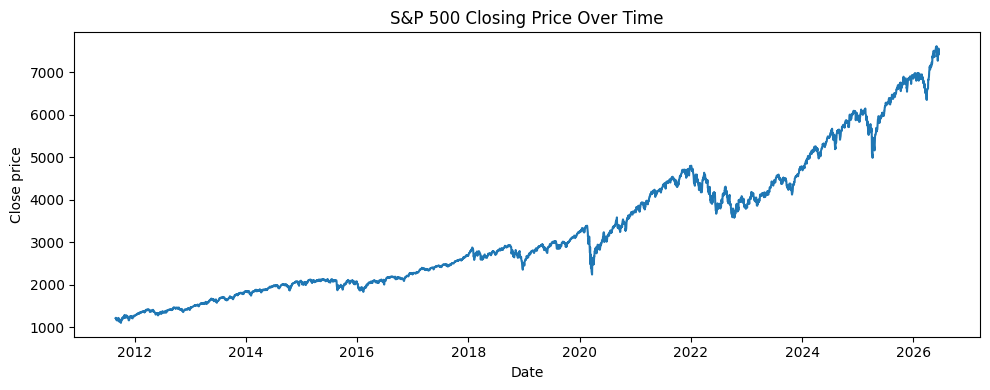

In [43]:
# 2.3 Closing price over time (shows the upward trend / non-stationarity)

plt.figure(figsize=(10,4))
plt.plot(df.index, df['Close'])
plt.title("S&P 500 Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Close price")
plt.tight_layout()
plt.savefig("eda_price.png", dpi=150)
plt.show()

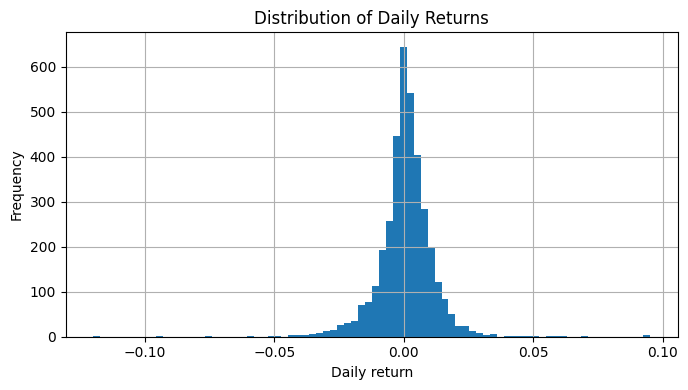

In [44]:
# 2.4 Distribution of daily returns

plt.figure(figsize=(7,4))
df['return'].hist(bins=80)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily return"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_returns.png", dpi=150)
plt.show()

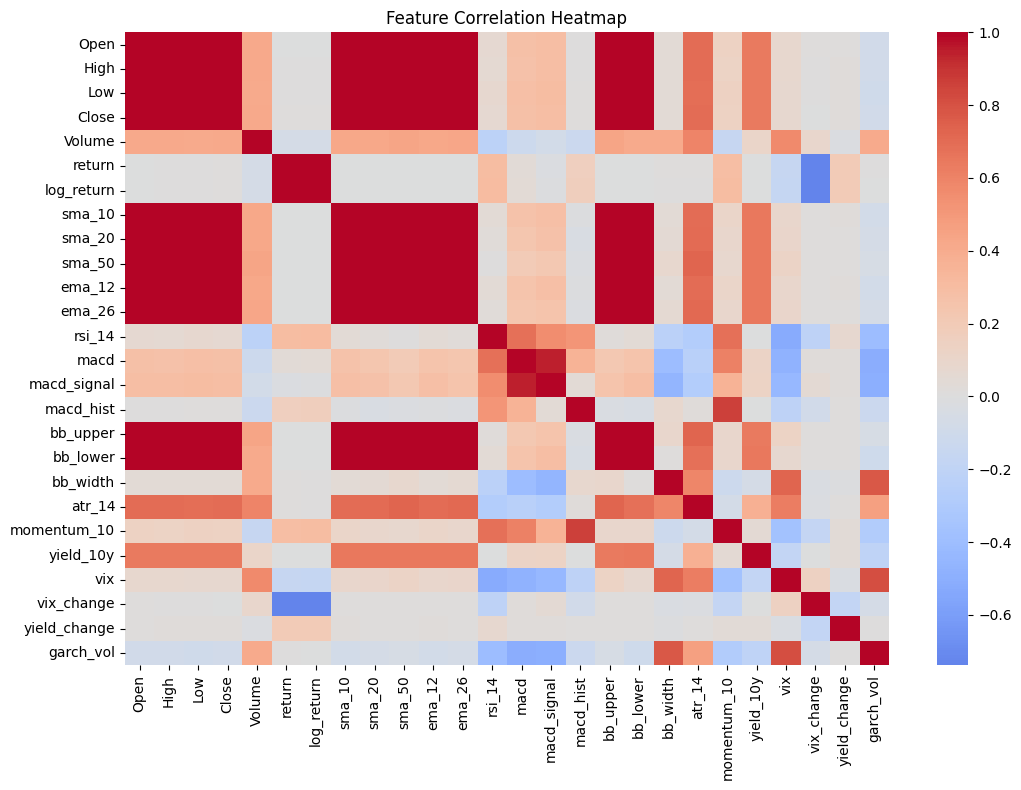

In [45]:
# 2.5 Feature correlation heatmap (key for your RQ3 — shows the indicators are correlated)

plt.figure(figsize=(11,8))
sns.heatmap(df.drop(columns=['target_up','next_return']).corr(),
            cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_corr.png", dpi=150)
plt.show()

In [46]:
# Download the outputs to keep them

from google.colab import files
for f in ["eda_describe.csv", "eda_price.png", "eda_returns.png", "eda_corr.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
# 3. Modelling and Tunning

!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 923.4 kB/s eta 0:00:00


In [48]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_row(name, y_true, y_pred):
    return {"model": name,
            "accuracy":  round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
            "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
            "f1":        round(f1_score(y_true, y_pred, zero_division=0), 4)}

In [49]:
# 3.1 Features and target

DROP_COLS = ["target_up", "next_return"]            # not model inputs
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].astype("float32")
y = df["target_up"].astype("int").values
print("Features:", len(feature_cols), "| samples:", len(X))

Features: 26 | samples: 3722


In [50]:
# 3.1b Shock-smoothing (winsorize extreme return/macro days, train-bounds only)
cut = int(len(X) * 0.8)
shock_cols = [c for c in ["return", "log_return", "vix_change", "yield_change"]
              if c in X.columns]
lower = X[shock_cols].iloc[:cut].quantile(0.01)
upper = X[shock_cols].iloc[:cut].quantile(0.99)
X[shock_cols] = X[shock_cols].clip(lower=lower, upper=upper, axis=1)
print("Smoothed shocks — winsorized:", shock_cols)

Smoothed shocks — winsorized: ['return', 'log_return', 'vix_change', 'yield_change']


In [51]:
# 3.2 Chronological split + scaling (no leakage)

TEST_FRACTION = 0.20
cut = int(len(X) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y[:cut], y[cut:]

scaler = StandardScaler().fit(X_train)              # fit on TRAIN ONLY
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", len(X_train), " Test:", len(X_test))

results = []                                        # we collect each model's score here

Train: 2977  Test: 745


In [52]:
# 3.3 Naive baseline (the score to beat: ~54.6%)

majority = int(round(y_train.mean()))
naive_pred = np.full_like(y_test, majority)
results.append(metrics_row("Naive (majority)", y_test, naive_pred))
results[-1]

{'model': 'Naive (majority)',
 'accuracy': 0.5705,
 'precision': 0.5705,
 'recall': 1.0,
 'f1': 0.7265}

In [53]:
# 3.4 Random Forest, tuned with TimeSeriesSplit

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=TimeSeriesSplit(n_splits=5),
    scoring="accuracy", n_jobs=-1, verbose=1)
rf_search.fit(X_train_s, y_train)
print("Best RF params:", rf_search.best_params_)

rf_pred = rf_search.best_estimator_.predict(X_test_s)
results.append(metrics_row("Random Forest (tuned)", y_test, rf_pred))
results[-1]

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}


{'model': 'Random Forest (tuned)',
 'accuracy': 0.4376,
 'precision': 0.5441,
 'recall': 0.0871,
 'f1': 0.1501}

In [54]:
# 3.5 Build sequences for the LSTM/GRU (with a chronological validation split)

LOOKBACK = 30
VAL_FRACTION = 0.20

def make_sequences(X2d, y1d, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(lookback, len(X2d)):
        Xs.append(X2d[i-lookback:i]); ys.append(y1d[i])
    return np.array(Xs), np.array(ys)

vcut = int(len(X_train_s) * (1 - VAL_FRACTION))     # validation = last part of TRAIN
Xtr_seq, ytr_seq   = make_sequences(X_train_s[:vcut], y_train[:vcut])
Xval_seq, yval_seq = make_sequences(X_train_s[vcut:], y_train[vcut:])
Xte_seq,  yte_seq  = make_sequences(X_test_s, y_test)
n_features = X_train_s.shape[1]
print("Train seq:", Xtr_seq.shape, "| Val:", Xval_seq.shape, "| Test:", Xte_seq.shape)

Train seq: (2351, 30, 26) | Val: (566, 30, 26) | Test: (715, 30, 26)


In [55]:
# 3.6 Define the model for the tuner

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential([keras.Input(shape=(LOOKBACK, n_features))])
    rnn = layers.LSTM if hp.Choice("rnn", ["lstm", "gru"]) == "lstm" else layers.GRU
    n_layers = hp.Int("n_layers", 1, 2)
    units    = hp.Choice("units", [32, 64, 128])
    dropout  = hp.Float("dropout", 0.1, 0.4, step=0.1)
    lr       = hp.Choice("lr", [1e-3, 5e-4, 1e-4])
    for i in range(n_layers):
        model.add(rnn(units, return_sequences=(i < n_layers - 1)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [56]:
# 3.7 Run the search (this is the slow part)

tuner = kt.Hyperband(build_model, objective="val_accuracy", max_epochs=30,
                     factor=3, directory="kt_dir", project_name="rnn_sp500",
                     overwrite=True)
stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                     restore_best_weights=True)
tuner.search(Xtr_seq, ytr_seq, validation_data=(Xval_seq, yval_seq),
             epochs=30, batch_size=32, callbacks=[stop], verbose=1)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best deep-model params:", best_hp.values)

Trial 90 Complete [00h 00m 34s]
val_accuracy: 0.5318021178245544

Best val_accuracy So Far: 0.554770290851593
Total elapsed time: 00h 27m 12s
Best deep-model params: {'rnn': 'gru', 'n_layers': 1, 'units': 32, 'dropout': 0.4, 'lr': 0.001, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 1, 'tuner/round': 0}


In [72]:
# 3.8 Retrain best config with class weights; pick threshold on VALIDATION (balanced acc), score once on TEST
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score

best_model = tuner.hypermodel.build(best_hp)

classes = np.unique(ytr_seq)
cw = compute_class_weight("balanced", classes=classes, y=ytr_seq)
class_weight = {int(c): w for c, w in zip(classes, cw)}

best_model.fit(Xtr_seq, ytr_seq, epochs=40, batch_size=32,
               class_weight=class_weight, verbose=0)

# choose threshold on VALIDATION using balanced accuracy (robust to class imbalance)
val_prob = best_model.predict(Xval_seq).ravel()
best_t, best_score = 0.5, 0
for t in np.arange(0.35, 0.65, 0.01):
    score = balanced_accuracy_score(yval_seq, (val_prob > t).astype(int))
    if score > best_score:
        best_score, best_t = score, t
print(f"Chosen threshold (from validation, balanced acc): {best_t:.2f}")

# final, one-shot evaluation on the untouched TEST set
dl_prob = best_model.predict(Xte_seq).ravel()
dl_pred = (dl_prob > best_t).astype(int)
dl_name = best_hp.values["rnn"].upper() + " (tuned)"
results.append(metrics_row(dl_name, yte_seq, dl_pred))
results[-1]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Chosen threshold (from validation, balanced acc): 0.36
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


{'model': 'GRU (tuned)',
 'accuracy': 0.4545,
 'precision': 0.5477,
 'recall': 0.2665,
 'f1': 0.3586}

In [58]:
# 3.9 The comparison table

import pandas as pd
comparison = pd.DataFrame(results).set_index("model")
comparison.to_csv("results_comparison.csv")
print("Naive baseline to beat: {:.1f}%".format(y_train.mean()*100))
comparison

Naive baseline to beat: 54.0%


,accuracy,precision,recall,f1
model,,,,
Naive (majority),0.5705,0.5705,1.0000,0.7265
Random Forest (tuned),0.4376,0.5441,0.0871,0.1501
GRU (tuned),0.4420,0.7500,0.0367,0.0699


In [59]:
# 3.10 Keep only the most recent GRU entry, drop the older duplicate
seen = {}
for row in results:
    seen[row["model"]] = row        # later entry overwrites earlier one
results = list(seen.values())
results

[{'model': 'Naive (majority)',
  'accuracy': 0.5705,
  'precision': 0.5705,
  'recall': 1.0,
  'f1': 0.7265},
 {'model': 'Random Forest (tuned)',
  'accuracy': 0.4376,
  'precision': 0.5441,
  'recall': 0.0871,
  'f1': 0.1501},
 {'model': 'GRU (tuned)',
  'accuracy': 0.442,
  'precision': 0.75,
  'recall': 0.0367,
  'f1': 0.0699}]

In [60]:
# 4. SHAP/LIME (explainability)

!pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [61]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rf_model = rf_search.best_estimator_     # the tuned Random Forest from earlier

In [62]:
# 4.1 SHAP values (exact, on a sample of the test set)

explainer = shap.TreeExplainer(rf_model)
X_sample = X_test_s[:500]                # a slice for speed
sv = np.array(explainer.shap_values(X_sample))

# make the SHAP array shape consistent across versions -> (samples, features) for "up"
if sv.ndim == 3:
    sv_pos = sv[1] if sv.shape[0] == 2 else sv[:, :, 1]
else:
    sv_pos = sv
print("SHAP values shape:", sv_pos.shape)

SHAP values shape: (500, 26)


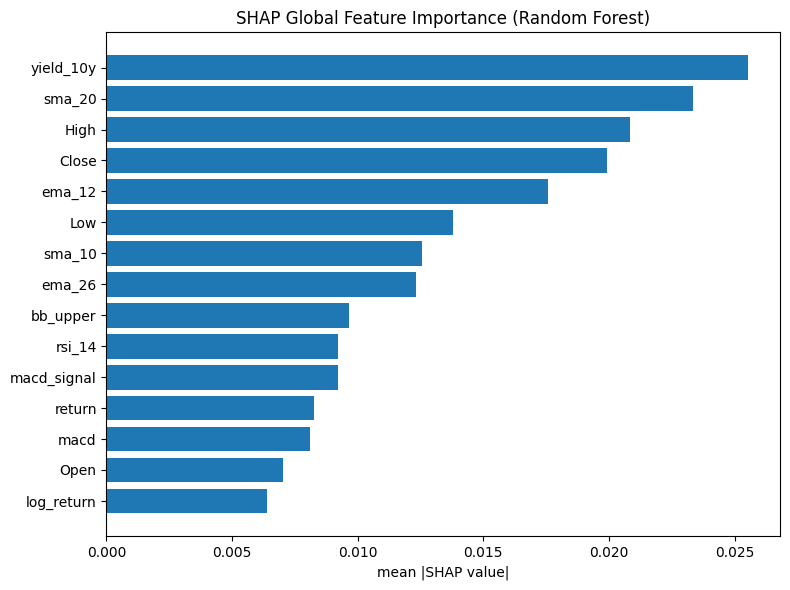

In [63]:
# 4.2 SHAP global feature importance (answers RQ2: which features matter most)

mean_abs = np.abs(sv_pos).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:15]          # top 15 features
plt.figure(figsize=(8,6))
plt.barh([feature_cols[i] for i in order][::-1], mean_abs[order][::-1])
plt.title("SHAP Global Feature Importance (Random Forest)")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.savefig("shap_global.png", dpi=150)
plt.show()

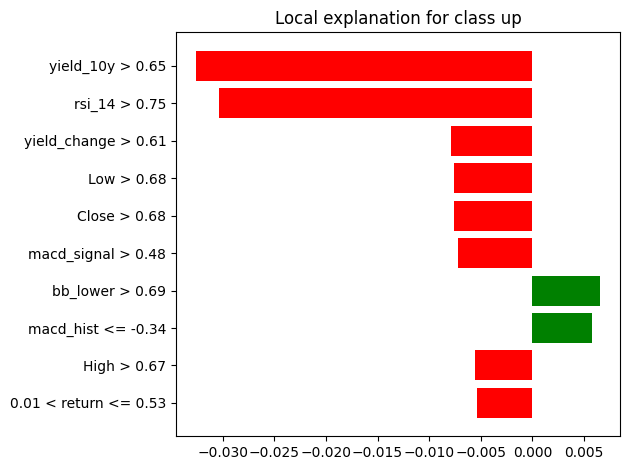

[('yield_10y > 0.65', -0.03257981624416382), ('rsi_14 > 0.75', -0.03038456521960315), ('yield_change > 0.61', -0.007842146942993268), ('Low > 0.68', -0.007567608239494104), ('Close > 0.68', -0.007561912979230407), ('macd_signal > 0.48', -0.007181220185804828), ('bb_lower > 0.69', 0.006536864847772407), ('macd_hist <= -0.34', 0.005757154090514334), ('High > 0.67', -0.0055201940443918626), ('0.01 < return <= 0.53', -0.005340967141422565)]


In [64]:
# 4.3 LIME local explanation (answers RQ2: why one specific prediction)

from lime.lime_tabular import LimeTabularExplainer

lime_exp = LimeTabularExplainer(
    X_train_s, feature_names=feature_cols,
    class_names=["down", "up"], mode="classification", random_state=42)

i = 0   # explain the first day in the test set
exp = lime_exp.explain_instance(X_test_s[i], rf_model.predict_proba, num_features=10)
exp.as_pyplot_figure()
plt.tight_layout(); plt.savefig("lime_local.png", dpi=150, bbox_inches="tight"); plt.show()
print(exp.as_list())


In [65]:
# 4.4 RQ3 reliability check: is LIME stable? (run it 5× and see if the top features change)

for seed in range(5):
    le = LimeTabularExplainer(X_train_s, feature_names=feature_cols,
                              class_names=["down", "up"], mode="classification",
                              random_state=seed)
    e = le.explain_instance(X_test_s[0], rf_model.predict_proba, num_features=5)
    print(f"run {seed}:", [f for f, _ in e.as_list()])

run 0: ['rsi_14 > 0.75', 'yield_10y > 0.65', 'Close > 0.68', 'High > 0.67', 'macd_signal > 0.48']
run 1: ['yield_10y > 0.65', 'rsi_14 > 0.75', 'Close > 0.68', 'yield_change > 0.61', 'macd_hist <= -0.34']
run 2: ['rsi_14 > 0.75', 'yield_10y > 0.65', 'Close > 0.68', 'High > 0.67', 'yield_change > 0.61']
run 3: ['yield_10y > 0.65', 'rsi_14 > 0.75', 'Close > 0.68', 'Low > 0.68', 'High > 0.67']
run 4: ['rsi_14 > 0.75', 'yield_10y > 0.65', 'Close > 0.68', 'macd_signal > 0.48', 'sma_20 > 0.67']


In [66]:
# 4.5 RQ2/RQ3 agreement check: does SHAP agree with the model's own importances?

shap_rank = pd.Series(mean_abs, index=feature_cols)
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols)
compare = pd.DataFrame({
    "SHAP_importance": shap_rank,
    "RF_builtin_importance": rf_imp
}).sort_values("SHAP_importance", ascending=False)
print(compare.head(10).round(4))
print("\nSpearman rank correlation:",
      round(shap_rank.rank().corr(rf_imp.rank(), method="spearman"), 3))

           SHAP_importance  RF_builtin_importance
yield_10y           0.0255                 0.0575
sma_20              0.0234                 0.0258
High                0.0208                 0.0300
Close               0.0199                 0.0263
ema_12              0.0176                 0.0223
Low                 0.0138                 0.0272
sma_10              0.0126                 0.0259
ema_26              0.0123                 0.0269
bb_upper            0.0097                 0.0301
rsi_14              0.0092                 0.0503

Spearman rank correlation: -0.288


In [67]:
from google.colab import files
for f in ["shap_global.png", "lime_local.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
# rebuild the threshold (from validation) and dl_pred — model is already in memory
from sklearn.metrics import accuracy_score
import numpy as np

val_prob = best_model.predict(Xval_seq).ravel()
best_t, best_acc = 0.5, 0
for t in np.arange(0.35, 0.65, 0.01):
    acc = accuracy_score(yval_seq, (val_prob > t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t
print("threshold:", round(best_t, 2))

dl_prob = best_model.predict(Xte_seq).ravel()
dl_pred = (dl_prob > best_t).astype(int)
np.save("dl_pred.npy", dl_pred)
print("dl_pred ready:", dl_pred.shape)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
threshold: 0.58
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
dl_pred ready: (715,)


In [69]:
# 5. Economic evaluation
# Line up predictions with the actual next-day returns

import numpy as np
import matplotlib.pyplot as plt

# the real next-day returns for exactly the days your model predicted on
test_next_ret = df["next_return"].iloc[cut + LOOKBACK:].values
assert len(test_next_ret) == len(dl_pred), "length mismatch — check cut/LOOKBACK"
print("Aligned days:", len(test_next_ret))

Aligned days: 715


In [70]:
# 5.1 Build the strategy vs buy-and-hold

# Strategy: be invested when the model predicts "up" (1), otherwise hold cash (0).
strategy_ret = dl_pred * test_next_ret      # capture the return only on predicted-up days
buyhold_ret  = test_next_ret                # always invested

def total_return(r): return float(np.prod(1 + r) - 1)
def sharpe(r):       return float(np.mean(r) / (np.std(r) + 1e-12) * np.sqrt(252))

print("Strategy   — total return: {:.1%}  | Sharpe: {:.2f}".format(
      total_return(strategy_ret), sharpe(strategy_ret)))
print("Buy & hold — total return: {:.1%}  | Sharpe: {:.2f}".format(
      total_return(buyhold_ret), sharpe(buyhold_ret)))

Strategy   — total return: 12.3%  | Sharpe: 1.56
Buy & hold — total return: 68.0%  | Sharpe: 1.28


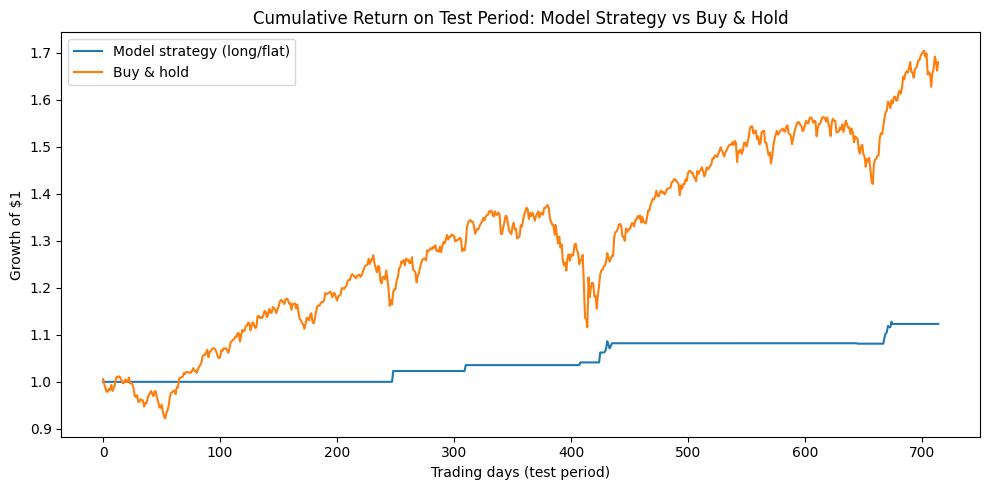

In [71]:
# 5.2 Plot the equity curves

plt.figure(figsize=(10,5))
plt.plot(np.cumprod(1 + strategy_ret), label="Model strategy (long/flat)")
plt.plot(np.cumprod(1 + buyhold_ret),  label="Buy & hold")
plt.title("Cumulative Return on Test Period: Model Strategy vs Buy & Hold")
plt.xlabel("Trading days (test period)"); plt.ylabel("Growth of $1")
plt.legend(); plt.tight_layout()
plt.savefig("economic_eval.png", dpi=150)
plt.show()